Imports

In [72]:
import numpy as np

from matplotlib import pyplot as plt

A function to calculate transfer function of a moving average filter with length $L$ and order $K$.

In [73]:
def calc_tran_fun(L, N_omegas, K=1):
    omegas = np.linspace(-np.pi, np.pi, N_omegas)
    Hz = np.zeros(np.shape(omegas))
    for d in range(0, L):
        Hz = Hz + np.exp(-1j * omegas * d)
    Hz = Hz / L
    HzK = Hz
    for k in range(0, K - 1):
        HzK *= Hz
    return Hz

Add example plots for the transfer functions of higher-order filters.

/tmp/ipykernel_14813/693349494.py:22: RuntimeWarning: divide by zero encountered in log10
  axes[k_idx, 1].plot(omegas, 10 * np.log10(np.abs(Hz_2)), label=r"Length = 2")
/tmp/ipykernel_14813/693349494.py:24: RuntimeWarning: divide by zero encountered in log10
  axes[k_idx, 1].plot(omegas, 10 * np.log10(np.abs(Hz_10)), label=r"Length = 10")


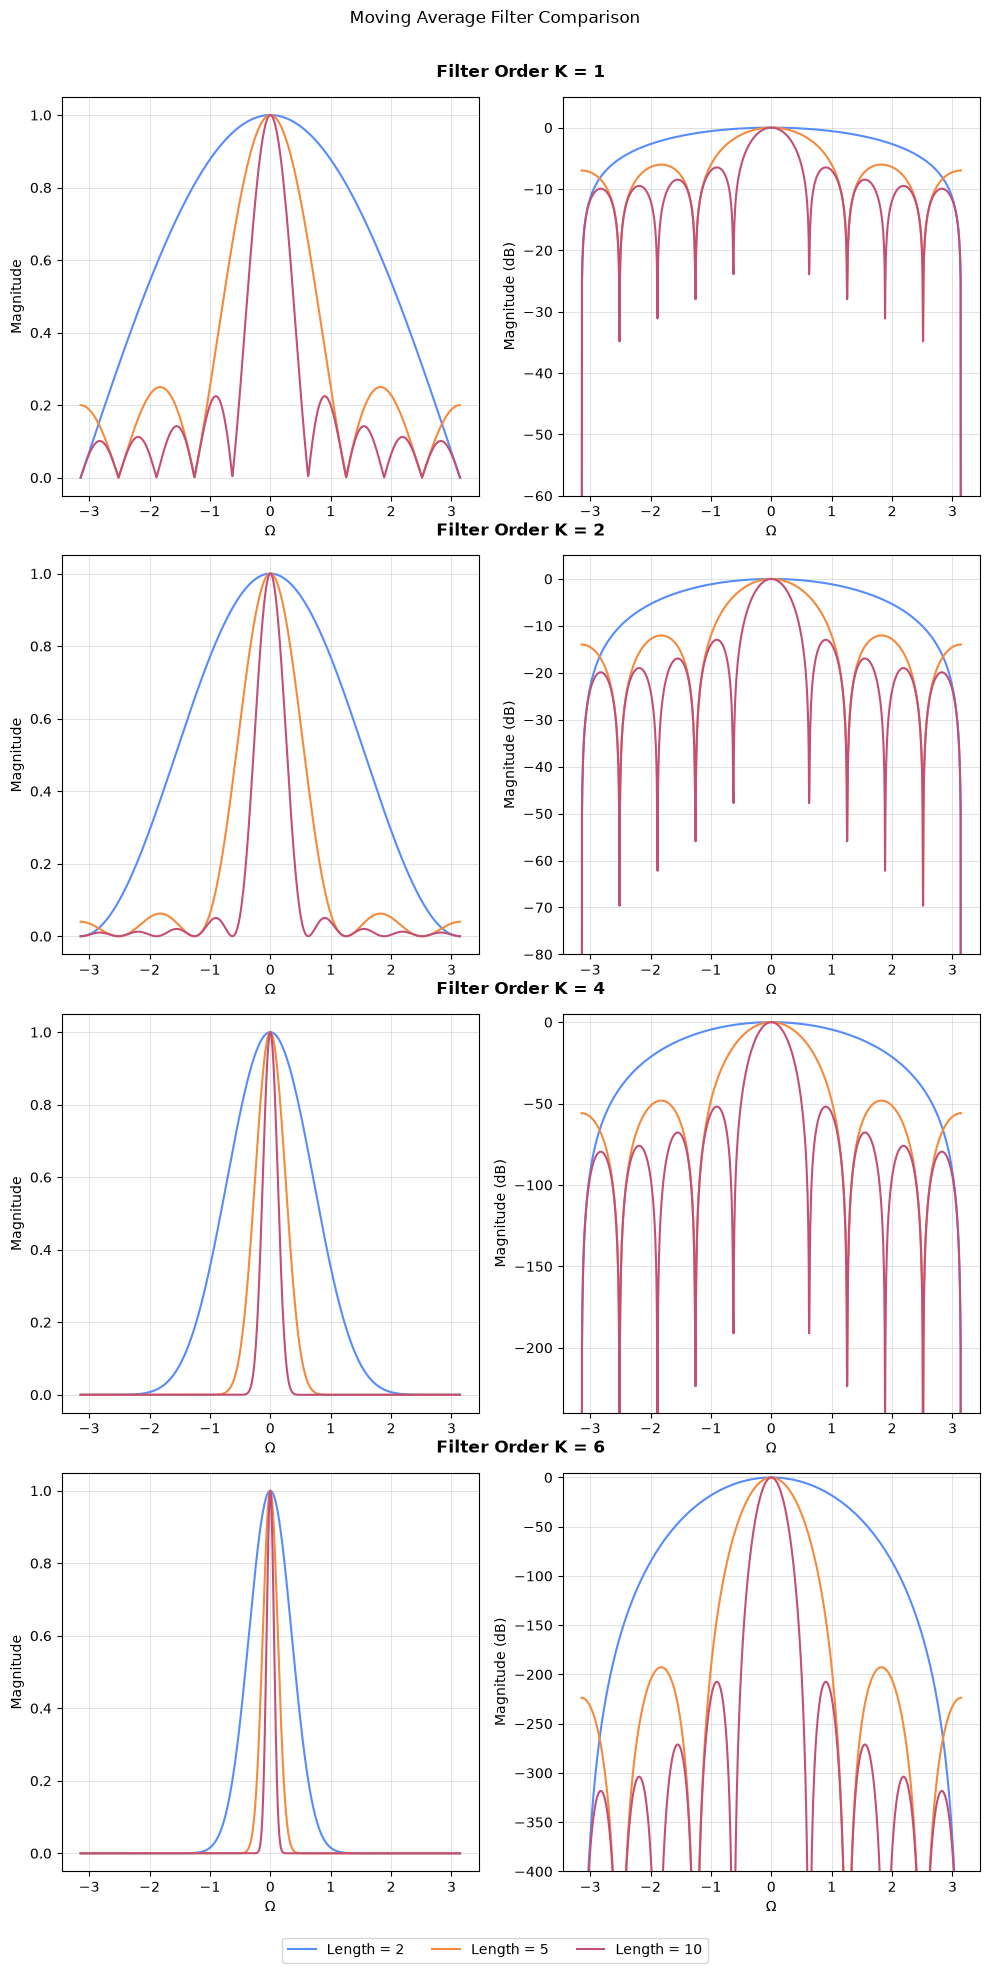

In [74]:
N_omegas = 1000

omegas = np.linspace(-np.pi, np.pi, N_omegas)

Ks = [1, 2, 4, 6]
y_min_vals = [-60, -80, -240, -400]

fig, axes = plt.subplots(len(Ks), 2, figsize=(10, 20))

for k_idx in range(0, len(Ks)):
    Hz_2 = calc_tran_fun(2, N_omegas, K=Ks[k_idx])
    Hz_5 = calc_tran_fun(5, N_omegas, K=Ks[k_idx])
    Hz_10 = calc_tran_fun(10, N_omegas, K=Ks[k_idx])

    axes[k_idx, 0].plot(omegas, np.abs(Hz_2), label=r"Length = 2")
    axes[k_idx, 0].plot(omegas, np.abs(Hz_5), label=r"Length = 5")
    axes[k_idx, 0].plot(omegas, np.abs(Hz_10), label=r"Length = 10")
    axes[k_idx, 0].set_xlabel(r"$\Omega$")
    axes[k_idx, 0].set_ylabel(r"Magnitude")
    axes[k_idx, 0].grid()

    axes[k_idx, 1].plot(omegas, 10 * np.log10(np.abs(Hz_2)), label=r"Length = 2")
    axes[k_idx, 1].plot(omegas, 10 * np.log10(np.abs(Hz_5)), label=r"Length = 5")
    axes[k_idx, 1].plot(omegas, 10 * np.log10(np.abs(Hz_10)), label=r"Length = 10")
    axes[k_idx, 1].set_xlabel(r"$\Omega$")
    axes[k_idx, 1].set_ylabel(r"Magnitude (dB)")
    axes[k_idx, 1].set_ylim([y_min_vals[k_idx], 5])
    axes[k_idx, 1].grid()

fig.suptitle("Moving Average Filter Comparison")

plt.tight_layout(rect=[0, 0.02, 1, 0.96])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0))

for k_idx in range(0, len(Ks)):
    pos_left = axes[k_idx, 0].get_position()
    pos_right = axes[k_idx, 1].get_position()
    fig.text(
        (pos_left.x0 + pos_right.x1) / 2,
        pos_left.y1 + 0.01,
        f"Filter Order K = {Ks[k_idx]}",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

plt.show()